# 05_02 Feature ablation for daily LightGBM Tweedie

Measure the incremental value of feature groups for the global daily Tweedie model. The **base specification** contains only IDs, calendar and forecast-position features, and local demand history. Each candidate specification adds exactly one remaining feature group to that base; the final specification restores all available features. This isolates each group's contribution without allowing later groups to mask earlier ones.

## Experimental controls

All specifications use the same eligible series, evaluation origins, seven-day horizon, expanding-origin training design, two-origin validation window, Tweedie variance power (1.5), hyperparameters, and WAPE early stopping as `05_01`. Models are independently refitted at every evaluation origin. Consequently, the only intentional difference between rows in the ablation table is the included feature set.

`Base + group` rows estimate isolated incremental value relative to the base. The all-features row measures the joint result, which need not equal the sum of isolated effects because LightGBM can learn interactions and substitute correlated signals.

In [1]:
from collections import OrderedDict
from pathlib import Path
from time import perf_counter
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/ba-matplotlib')

import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import (
    MODEL_COLUMNS, PRIMARY_MODEL, load_benchmark_design, run_benchmark,
    segment_wape, summarize_models,
)
from src.models.machine_learning.lightgbm import (
    CATEGORICAL_FEATURES, DIAGNOSTIC_COLUMNS, FEATURE_COLUMNS,
    FORECAST_ID_COLUMNS, GlobalLightGBMConfig, prepare_global_lightgbm_frames,
)
from src.models.machine_learning.lightgbm.gbm_base import (
    fit_lightgbm_model, lightgbm_feature_importance, wape_feval,
)
from src.models.machine_learning.lightgbm.lightgbm_variants import _base_model_params

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 160)
sns.set_theme(style='whitegrid', context='notebook')

## Feature specifications

The requested three groups form the base. Known actions, historical action behavior, maturity, demand regime, cross-sectional context, and baseline forecasts are tested separately. Any later-added production features not explicitly listed below are retained automatically as one `Operational supply signals` group, so the notebook remains aligned with `FEATURE_COLUMNS`.

In [2]:
BASE_GROUPS = OrderedDict({
    'IDs': (
        'ARTIKEL_ID', 'MARKT_ID', 'sourcing_group', 'category_id',
    ),
    'Calendar and forecast position': (
        'target_weekday', 'horizon_day', 'iso_week', 'month',
        'is_active', 'reason_closed',
        'is_public_holiday', 'days_to_nearest_event',
        'holiday_event_window', 'event_name',
    ),
    'Local demand history': (
        'lag_1', 'lag_7', 'lag_14', 'rolling_7_mean', 'rolling_28_mean',
        'rolling_28_demand_rate', 'rolling_28_positive_mean',
        'same_weekday_mean_4', 'same_weekday_mean_8',
    ),
})

CANDIDATE_GROUPS = OrderedDict({
    'Known action schedule': (
        'action_on_forecast_day', 'action_during_horizon',
    ),
    'Historical action behavior': (
        'days_since_last_action', 'actions_last_28d',
        'mean_action_lift_in_sourcing_group',
    ),
    'Maturity': (
        'active_days_before_origin', 'demand_days_before_origin',
        'demand_day_ratio', 'days_since_last_positive_sale',
        'maturity_segment',
    ),
    'Demand regime': ('ADI', 'CV2', 'zero_share'),
    'Cross-sectional context': (
        'product_cross_store_mean_28', 'product_weekday_profile_value',
        'store_category_mean_28',
    ),
    'Baseline forecasts': (
        'recent_mean_28_forecast', 'same_weekday_ma_4_forecast',
        'occurrence_positive_quantity_forecast',
    ),
})

declared_features = {
    feature
    for features in [*BASE_GROUPS.values(), *CANDIDATE_GROUPS.values()]
    for feature in features
}
unknown_declared = declared_features.difference(FEATURE_COLUMNS)
if unknown_declared:
    raise ValueError(f'Feature groups contain unknown columns: {sorted(unknown_declared)}')

operational_features = tuple(
    feature for feature in FEATURE_COLUMNS if feature not in declared_features
)
if operational_features:
    CANDIDATE_GROUPS['Operational supply signals'] = operational_features

base_features = tuple(
    feature for feature in FEATURE_COLUMNS
    if any(feature in group for group in BASE_GROUPS.values())
)

FEATURE_SETS = OrderedDict({'Base': base_features})
for group_name, group_features in CANDIDATE_GROUPS.items():
    FEATURE_SETS[f'Base + {group_name}'] = tuple(
        feature for feature in FEATURE_COLUMNS
        if feature in set(base_features).union(group_features)
    )
FEATURE_SETS['All features'] = tuple(FEATURE_COLUMNS)

feature_design = pd.DataFrame([
    {
        'specification': specification,
        'n_features': len(features),
        'added_to_base': (
            'None' if specification == 'Base'
            else 'All remaining groups' if specification == 'All features'
            else specification.removeprefix('Base + ')
        ),
        'features': ', '.join(features),
    }
    for specification, features in FEATURE_SETS.items()
])
display(feature_design)

,specification,n_features,added_to_base,features
0,Base,21,None,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."
1,Base + Known action schedule,23,Known action schedule,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."
2,Base + Historical action behavior,24,Historical action behavior,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."
3,Base + Maturity,26,Maturity,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."
4,Base + Demand regime,24,Demand regime,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."
5,Base + Cross-sectional context,24,Cross-sectional context,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."
6,Base + Baseline forecasts,24,Baseline forecasts,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."
7,Base + Operational supply signals,33,Operational supply signals,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."
8,All features,52,All remaining groups,"ARTIKEL_ID, MARKT_ID, sourcing_group, category..."


## Shared data and rolling-origin frames

In [3]:
design = load_benchmark_design()
config = GlobalLightGBMConfig()

started = perf_counter()
con = duckdb.connect()
con.execute("SET temp_directory='/tmp/ba_lightgbm_ablation_duckdb'")
benchmark = run_benchmark(
    design=design, connection=con, include_extended_baselines=False,
)
frames = prepare_global_lightgbm_frames(
    design=design,
    evaluation_origins=benchmark.origin_summary.origin,
    connection=con,
    config=config,
)
origin_frames = (
    list(frames.origin_frames.values())
    if isinstance(frames.origin_frames, dict)
    else list(frames.origin_frames)
)

display(pd.DataFrame([{
    'evaluation_origins': len(origin_frames),
    'evaluation_rows': len(frames.evaluation),
    'ablation_specifications': len(FEATURE_SETS),
    'model_refits': len(origin_frames) * len(FEATURE_SETS),
}]))

/Users/vlada/UNI/SoSe2026/ba/ba_code/src/models/machine_learning/lightgbm/lightgbm_features.py:982: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  available_origins = initial_history_origins.append(normalized_origins[:position])


,evaluation_origins,evaluation_rows,ablation_specifications,model_refits
0,9,1300152,9,81


## Fit every feature specification

Categorical encoding is restricted to categorical columns present in each feature set. Early stopping chooses the number of boosting rounds on the validation origins, after which the shared trainer refits on training plus validation rows.

In [4]:
def fit_tweedie_ablation(specification, feature_columns, origin_frames, config):
    model_id = 'tweedie_ablation_' + specification.lower().replace(' + ', '_').replace(' ', '_')
    categorical_features = tuple(
        feature for feature in CATEGORICAL_FEATURES if feature in feature_columns
    )
    forecast_parts = []
    summary_rows = []
    importance_parts = []

    for origin_frame in origin_frames:
        model, history, best_iteration = fit_lightgbm_model(
            training=origin_frame.training,
            validation=origin_frame.validation,
            labels=(
                origin_frame.training['actual'],
                origin_frame.validation['actual'],
            ),
            evaluation=origin_frame.evaluation,
            params={
                **_base_model_params(config),
                'objective': 'tweedie',
                'tweedie_variance_power': 1.5,
                'metric': 'None',
            },
            feature_columns=feature_columns,
            categorical_features=categorical_features,
            config=config,
            feval=wape_feval,
        )

        evaluation = origin_frame.evaluation
        forecasts = evaluation.loc[:, [
            *FORECAST_ID_COLUMNS, *DIAGNOSTIC_COLUMNS,
        ]].copy()
        forecasts['model'] = model_id
        forecasts['forecast'] = np.where(evaluation['is_active'], model.predict(evaluation), 0.0)
        forecast_parts.append(forecasts)

        evaluation_origin = pd.Timestamp(evaluation['origin'].iloc[0])
        summary_rows.append({
            'model': model_id,
            'specification': specification,
            'evaluation_origin': evaluation_origin,
            'fit_rows': len(origin_frame.training),
            'validation_rows': len(origin_frame.validation),
            'evaluation_rows': len(evaluation),
            'best_iteration': best_iteration,
            'features': len(feature_columns),
        })
        importance = lightgbm_feature_importance(model)
        importance['model'] = model_id
        importance['specification'] = specification
        importance['evaluation_origin'] = evaluation_origin
        importance_parts.append(importance)

    return {
        'model': model_id,
        'forecasts': pd.concat(forecast_parts, ignore_index=True),
        'training_summary': pd.DataFrame(summary_rows),
        'feature_importance': pd.concat(importance_parts, ignore_index=True),
    }


ablation_results = [
    fit_tweedie_ablation(specification, features, origin_frames, config)
    for specification, features in FEATURE_SETS.items()
]
ablation_forecasts = pd.concat(
    [result['forecasts'] for result in ablation_results], ignore_index=True,
)
training_summary = pd.concat(
    [result['training_summary'] for result in ablation_results], ignore_index=True,
)
feature_importance = pd.concat(
    [result['feature_importance'] for result in ablation_results], ignore_index=True,
)
MODEL_LABELS = {result['model']: result['training_summary'].specification.iloc[0] for result in ablation_results}
print(f'Runtime: {(perf_counter() - started) / 60:.2f} minutes')
display(training_summary.groupby('specification', sort=False).agg(
    refits=('evaluation_origin', 'nunique'),
    features=('features', 'first'),
    median_best_iteration=('best_iteration', 'median'),
    min_best_iteration=('best_iteration', 'min'),
    max_best_iteration=('best_iteration', 'max'),
).reset_index().style.format({
    'features': '{:,.0f}', 'refits': '{:,.0f}',
    'median_best_iteration': '{:,.0f}', 'min_best_iteration': '{:,.0f}',
    'max_best_iteration': '{:,.0f}',
}))

Runtime: 48.41 minutes


,specification,refits,features,median_best_iteration,min_best_iteration,max_best_iteration
0,Base,9,21,465,41,500
1,Base + Known action schedule,9,23,474,213,500
2,Base + Historical action behavior,9,24,496,72,500
3,Base + Maturity,9,26,496,49,500
4,Base + Demand regime,9,24,232,51,500
5,Base + Cross-sectional context,9,24,500,40,500
6,Base + Baseline forecasts,9,24,318,45,500
7,Base + Operational supply signals,9,33,465,41,500
8,All features,9,52,316,137,483


## Overall ablation result

Positive `WAPE gain vs base` means that adding the group improves accuracy. Calibration is shown alongside accuracy to distinguish a genuine error reduction from systematic suppression or inflation of forecast volume.

In [5]:
summary = summarize_models(ablation_forecasts)
summary['specification'] = summary.model.map(MODEL_LABELS)
base_row = summary.loc[summary.specification.eq('Base')].iloc[0]
summary['wape_gain_vs_base_pp'] = 100 * (base_row.pooled_wape - summary.pooled_wape)
summary['absolute_error_reduction_vs_base_kg'] = (
    base_row.absolute_error_kg - summary.absolute_error_kg
    if 'absolute_error_kg' in summary
    else summary.actual_kg * (base_row.pooled_wape - summary.pooled_wape)
)
summary['feature_count'] = summary.specification.map(
    {name: len(features) for name, features in FEATURE_SETS.items()}
)
summary = summary.sort_values('pooled_wape').reset_index(drop=True)
display(summary[[
    'specification', 'feature_count', 'pooled_wape', 'wape_gain_vs_base_pp',
    'relative_bias', 'forecast_to_actual_ratio', 'median_series_wape',
    'seasonal_mase', 'mae_kg', 'actual_kg', 'forecast_kg',
]].style.format({
    'feature_count': '{:,.0f}', 'pooled_wape': '{:.2%}',
    'wape_gain_vs_base_pp': '{:+.2f}', 'relative_bias': '{:+.2%}',
    'forecast_to_actual_ratio': '{:.3f}', 'median_series_wape': '{:.2%}',
    'seasonal_mase': '{:.3f}', 'mae_kg': '{:.3f}',
    'actual_kg': '{:,.1f}', 'forecast_kg': '{:,.1f}',
}).background_gradient(subset=['wape_gain_vs_base_pp'], cmap='RdYlGn'))

,specification,feature_count,pooled_wape,wape_gain_vs_base_pp,relative_bias,forecast_to_actual_ratio,median_series_wape,seasonal_mase,mae_kg,actual_kg,forecast_kg
0,All features,52,60.89%,+31.81,-10.59%,0.894,93.37%,0.664,0.541,"1,156,111.7","1,033,674.5"
1,Base + Known action schedule,23,61.15%,+31.54,-13.40%,0.866,93.17%,0.667,0.544,"1,156,111.7","1,001,167.4"
2,Base + Historical action behavior,24,87.13%,+5.57,-17.21%,0.828,122.74%,0.843,0.775,"1,156,111.7","957,179.5"
3,Base + Maturity,26,90.57%,+2.12,-16.58%,0.834,127.25%,0.872,0.805,"1,156,111.7","964,482.2"
4,Base + Cross-sectional context,24,91.00%,+1.69,-19.04%,0.810,125.41%,0.876,0.809,"1,156,111.7","936,029.9"
5,Base + Baseline forecasts,24,91.64%,+1.06,-14.94%,0.851,127.34%,0.886,0.815,"1,156,111.7","983,417.5"
6,Base + Demand regime,24,92.26%,+0.44,-14.71%,0.853,126.78%,0.870,0.820,"1,156,111.7","986,033.4"
7,Base,21,92.69%,+0.00,-14.33%,0.857,127.82%,0.893,0.824,"1,156,111.7","990,498.6"
8,Base + Operational supply signals,33,92.69%,-0.00,-14.33%,0.857,127.82%,0.893,0.824,"1,156,111.7","990,498.6"


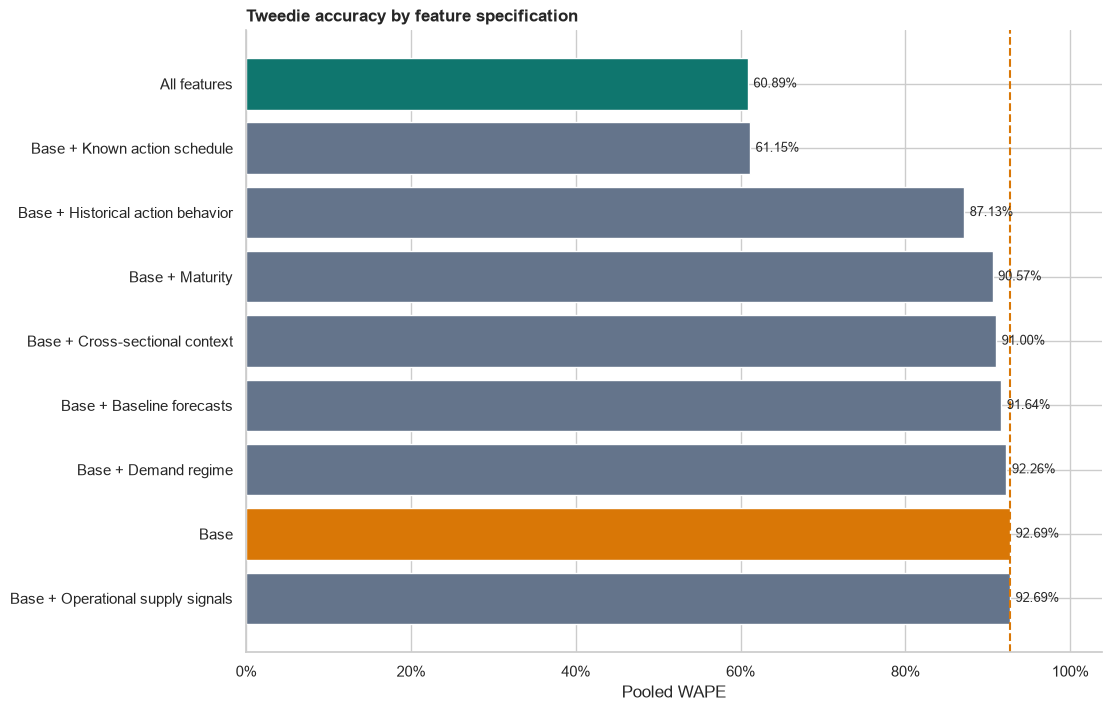

In [6]:
wape_plot = summary.sort_values('pooled_wape', ascending=False).copy()
wape_plot['is_base'] = wape_plot.specification.eq('Base')
wape_plot['is_all_features'] = wape_plot.specification.eq('All features')
wape_colors = np.select(
    [wape_plot.is_base, wape_plot.is_all_features],
    ['#d97706', '#0f766e'],
    default='#64748b',
)
fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
bars = ax.barh(
    wape_plot.specification, wape_plot.pooled_wape, color=wape_colors,
)
ax.axvline(base_row.pooled_wape, color='#d97706', linestyle='--', linewidth=1.5)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel('Pooled WAPE')
ax.set_ylabel('')
ax.set_title('Tweedie accuracy by feature specification', loc='left', weight='bold')
ax.bar_label(
    bars, labels=[f'{value:.2%}' for value in wape_plot.pooled_wape],
    padding=4, fontsize=9,
)
ax.margins(x=.12)
sns.despine(fig=fig)
plt.show()

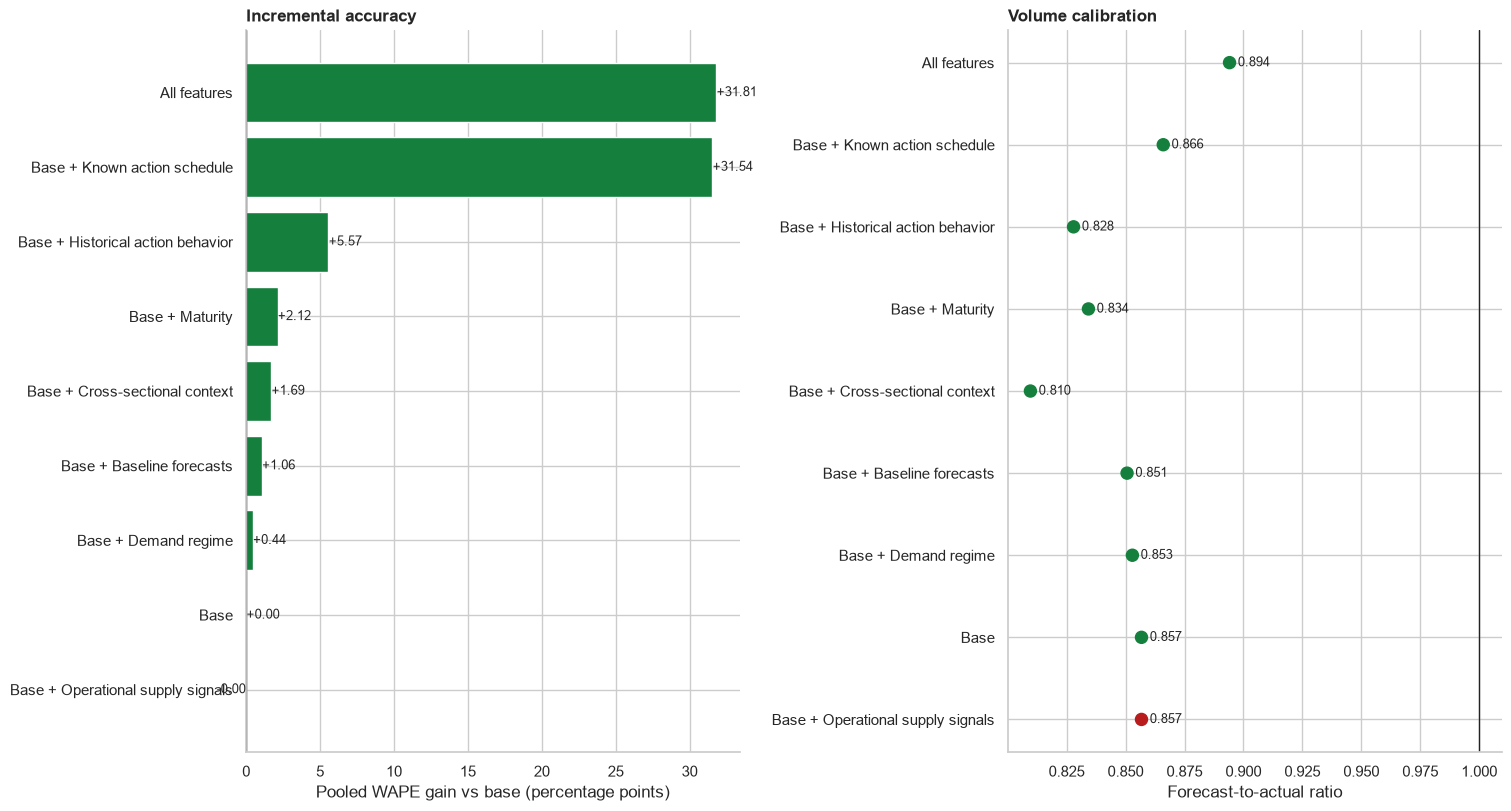

In [7]:
plot_summary = summary.sort_values('wape_gain_vs_base_pp')
colors = np.where(plot_summary.wape_gain_vs_base_pp.ge(0), '#15803d', '#b91c1c')
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)

axes[0].barh(
    plot_summary.specification, plot_summary.wape_gain_vs_base_pp, color=colors,
)
axes[0].axvline(0, color='#222222', linewidth=1)
axes[0].set_xlabel('Pooled WAPE gain vs base (percentage points)')
axes[0].set_ylabel('')
axes[0].set_title('Incremental accuracy', loc='left', weight='bold')
for y, value in enumerate(plot_summary.wape_gain_vs_base_pp):
    axes[0].text(
        value + (0.03 if value >= 0 else -0.03), y, f'{value:+.2f}',
        ha='left' if value >= 0 else 'right', va='center', fontsize=9,
    )

axes[1].axvline(1, color='#222222', linewidth=1)
axes[1].scatter(
    plot_summary.forecast_to_actual_ratio, plot_summary.specification,
    c=colors, s=75,
)
axes[1].set_xlabel('Forecast-to-actual ratio')
axes[1].set_ylabel('')
axes[1].set_title('Volume calibration', loc='left', weight='bold')
for y, value in enumerate(plot_summary.forecast_to_actual_ratio):
    axes[1].annotate(
        f'{value:.3f}', (value, y), xytext=(6, 0),
        textcoords='offset points', va='center', fontsize=9,
    )
sns.despine(fig=fig)
plt.show()

## Stability across evaluation origins

A feature group is more credible when its aggregate gain is repeated across origins rather than driven by one unusually favorable window.

,specification,origins_improved,origins_evaluated,mean_wape_gain_pp,median_wape_gain_pp,worst_wape_gain_pp
0,All features,9,9,+32.16,+33.37,+21.61
5,Base + Known action schedule,9,9,+32.03,+32.12,+22.56
4,Base + Historical action behavior,6,9,+6.03,+2.06,-4.22
2,Base + Cross-sectional context,7,9,+1.84,+1.59,-0.03
6,Base + Maturity,5,9,+1.82,+2.45,-5.10
1,Base + Baseline forecasts,6,9,+1.05,+0.22,-0.19
3,Base + Demand regime,5,9,+0.41,+0.70,-3.31
7,Base + Operational supply signals,1,9,-0.00,-0.00,-0.00


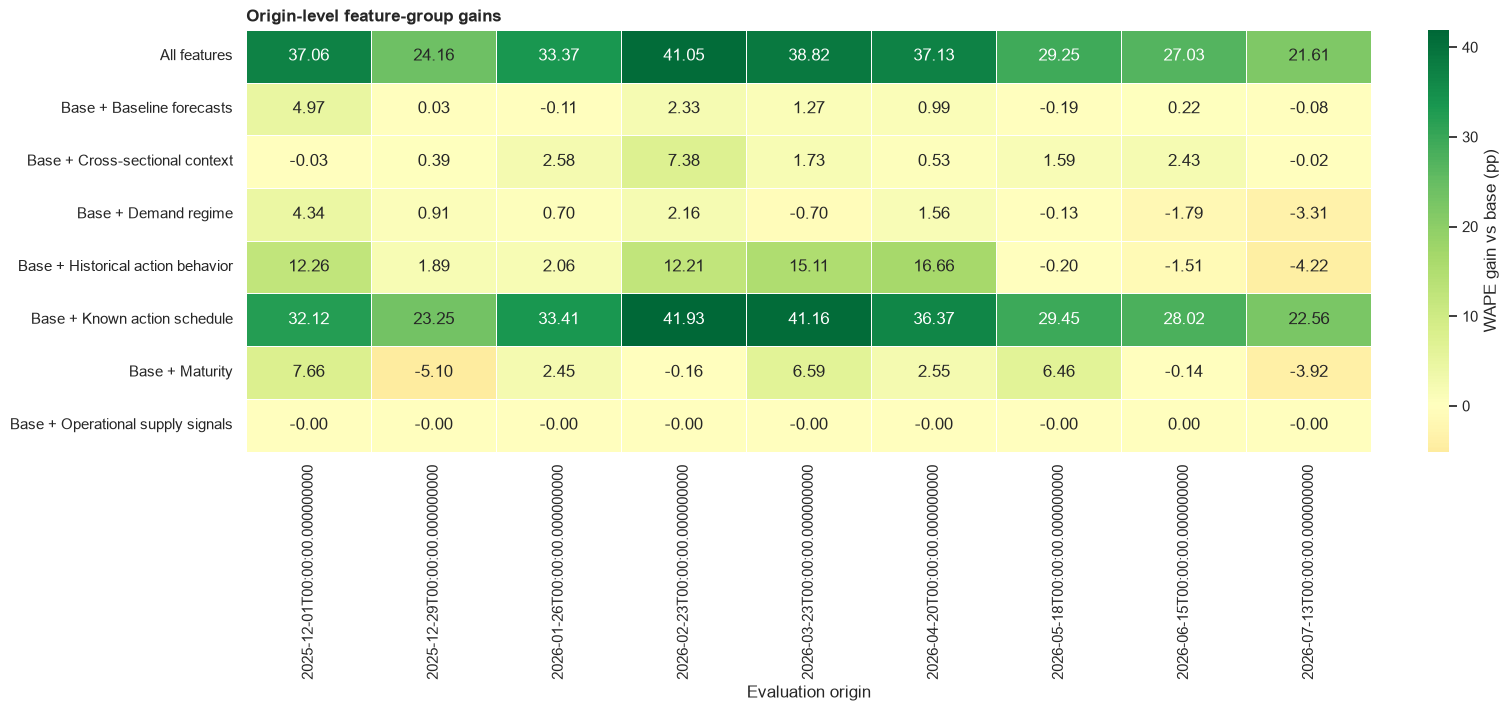

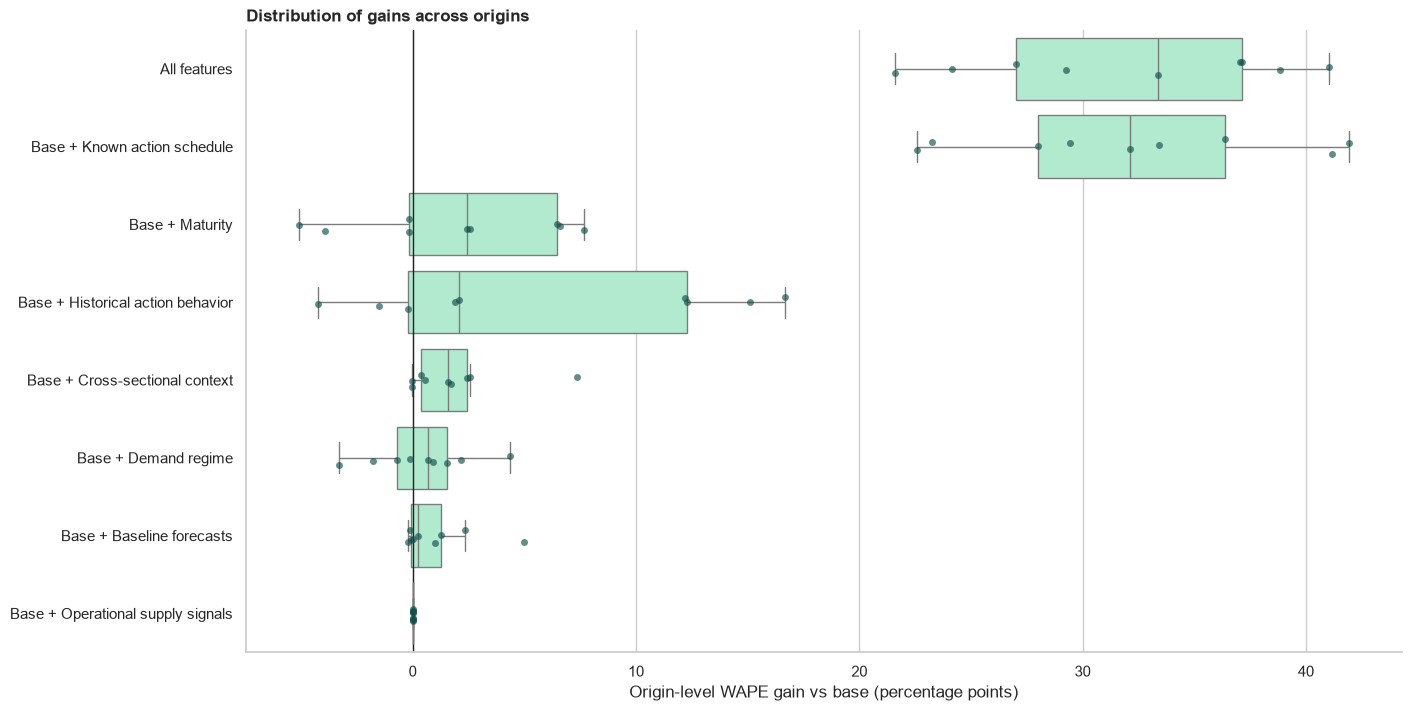

In [8]:
origin_result = segment_wape(ablation_forecasts, 'origin')
origin_result['specification'] = origin_result.model.map(MODEL_LABELS)
origin_wide = origin_result.pivot(
    index='origin', columns='specification', values='pooled_wape',
)
origin_delta = origin_wide.sub(origin_wide['Base'], axis=0).drop(columns='Base')
origin_stability = pd.DataFrame({
    'specification': origin_delta.columns,
    'origins_improved': origin_delta.lt(0).sum().to_numpy(),
    'origins_evaluated': origin_delta.notna().sum().to_numpy(),
    'mean_wape_gain_pp': (-100 * origin_delta.mean()).to_numpy(),
    'median_wape_gain_pp': (-100 * origin_delta.median()).to_numpy(),
    'worst_wape_gain_pp': (-100 * origin_delta.max()).to_numpy(),
}).sort_values('mean_wape_gain_pp', ascending=False)
display(origin_stability.style.format({
    'origins_improved': '{:,.0f}', 'origins_evaluated': '{:,.0f}',
    'mean_wape_gain_pp': '{:+.2f}', 'median_wape_gain_pp': '{:+.2f}',
    'worst_wape_gain_pp': '{:+.2f}',
}))

fig, ax = plt.subplots(figsize=(15, 7), constrained_layout=True)
sns.heatmap(
    -100 * origin_delta.T, center=0, cmap='RdYlGn', annot=True, fmt='.2f',
    linewidths=.5, cbar_kws={'label': 'WAPE gain vs base (pp)'}, ax=ax,
)
ax.set_xlabel('Evaluation origin')
ax.set_ylabel('')
ax.set_title('Origin-level feature-group gains', loc='left', weight='bold')
plt.show()

origin_gain_long = (
    (-100 * origin_delta)
    .rename_axis(index='origin', columns='specification')
    .stack().rename('wape_gain_pp').reset_index()
)
origin_order = (
    origin_gain_long.groupby('specification', observed=True).wape_gain_pp
    .median().sort_values(ascending=False).index
)
fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)
sns.boxplot(
    data=origin_gain_long, x='wape_gain_pp', y='specification',
    order=origin_order, color='#a7f3d0', fliersize=0, ax=ax,
)
sns.stripplot(
    data=origin_gain_long, x='wape_gain_pp', y='specification',
    order=origin_order, color='#134e4a', alpha=.65, size=5, ax=ax,
)
ax.axvline(0, color='#222222', linewidth=1)
ax.set_xlabel('Origin-level WAPE gain vs base (percentage points)')
ax.set_ylabel('')
ax.set_title('Distribution of gains across origins', loc='left', weight='bold')
sns.despine(fig=fig)
plt.show()

## Which added features are used?

Gain importance is averaged over origin-specific refits. Importance does not establish causal value, but it helps explain whether an added group contributes through one dominant signal or several complementary signals.

,feature,mean_gain_share,mean_splits,added_group
16,occurrence_positive_quantity_forecast,7.79%,299.7,Baseline forecasts
17,recent_mean_28_forecast,1.45%,48.0,Baseline forecasts
18,same_weekday_ma_4_forecast,0.05%,18.9,Baseline forecasts
13,product_cross_store_mean_28,1.79%,"1,389.3",Cross-sectional context
15,store_category_mean_28,0.67%,260.7,Cross-sectional context
14,product_weekday_profile_value,0.57%,402.6,Cross-sectional context
12,zero_share,1.23%,221.0,Demand regime
10,ADI,1.09%,231.3,Demand regime
11,CV2,0.11%,135.6,Demand regime
3,days_since_last_action,4.10%,"1,297.4",Historical action behavior


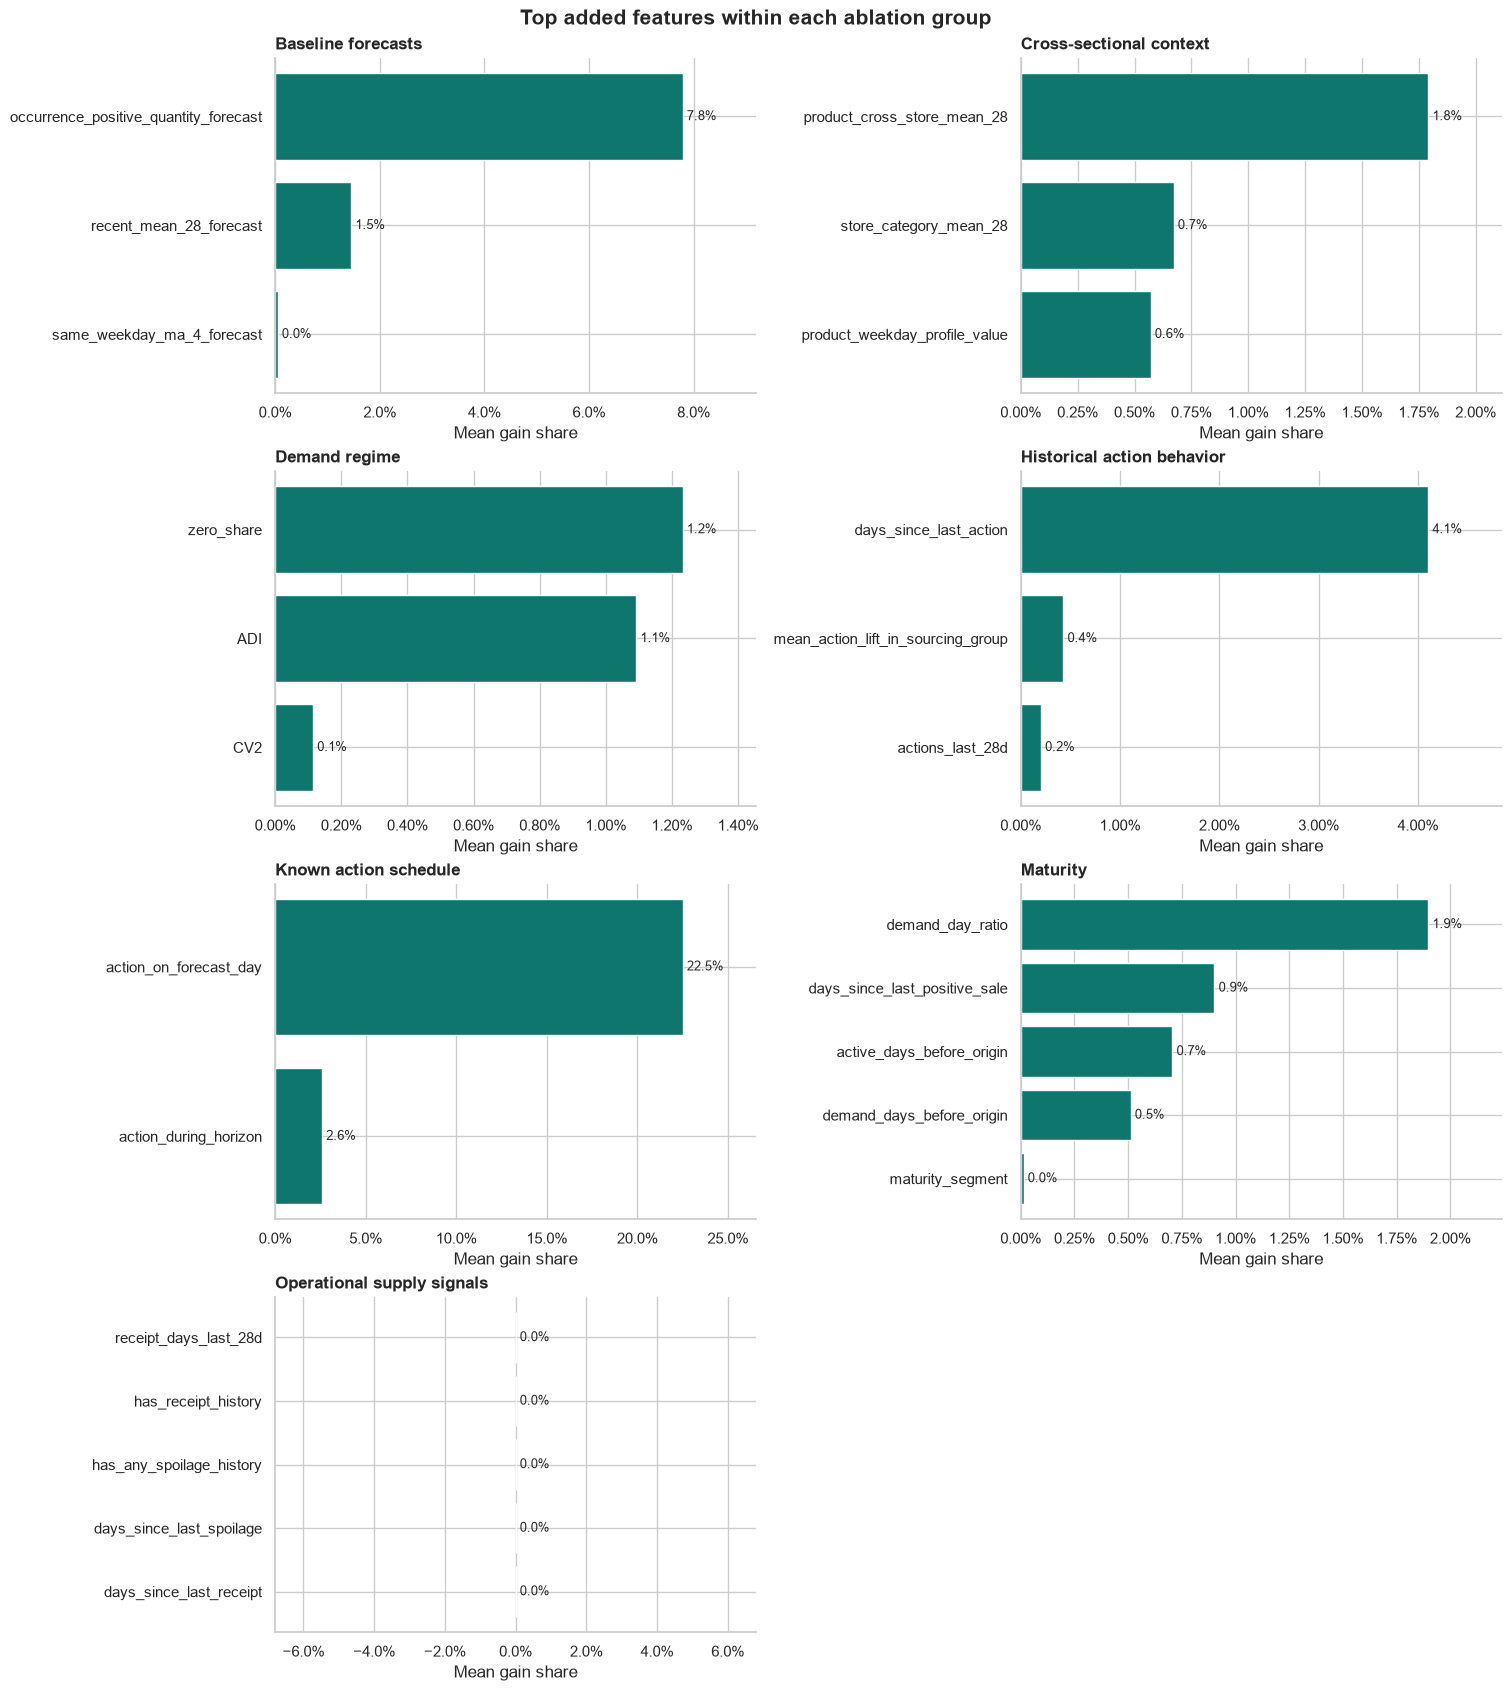

In [9]:
added_feature_rows = []
for specification, group_features in CANDIDATE_GROUPS.items():
    label = f'Base + {specification}'
    panel = feature_importance.loc[
        feature_importance.specification.eq(label)
        & feature_importance.feature.isin(group_features)
    ]
    grouped = panel.groupby('feature', observed=True).agg(
        mean_gain_share=('gain_share', 'mean'),
        mean_splits=('splits', 'mean'),
    ).reset_index()
    grouped['added_group'] = specification
    added_feature_rows.append(grouped)

added_feature_importance = pd.concat(added_feature_rows, ignore_index=True)
added_feature_importance = added_feature_importance.sort_values(
    ['added_group', 'mean_gain_share'], ascending=[True, False],
)
display(added_feature_importance.style.format({
    'mean_gain_share': '{:.2%}', 'mean_splits': '{:,.1f}',
}))

importance_plot = (
    added_feature_importance.sort_values(
        ['added_group', 'mean_gain_share'], ascending=[True, False],
    )
    .groupby('added_group', observed=True, sort=False).head(5)
)
groups = list(importance_plot.added_group.drop_duplicates())
ncols = 2
nrows = int(np.ceil(len(groups) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(15, 4.2 * nrows), squeeze=False,
    constrained_layout=True,
)
for ax, group in zip(axes.flat, groups):
    panel = (
        importance_plot.loc[importance_plot.added_group.eq(group)]
        .sort_values('mean_gain_share')
    )
    bars = ax.barh(panel.feature, panel.mean_gain_share, color='#0f766e')
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel('Mean gain share')
    ax.set_ylabel('')
    ax.set_title(group, loc='left', weight='bold')
    ax.bar_label(
        bars, labels=[f'{value:.1%}' for value in panel.mean_gain_share],
        padding=3, fontsize=9,
    )
    ax.margins(x=.18)
for ax in axes.flat[len(groups):]:
    ax.set_visible(False)
fig.suptitle(
    'Top added features within each ablation group', fontsize=15, weight='bold',
)
sns.despine(fig=fig)
plt.show()

## Selection rule

Prefer feature groups that improve pooled WAPE, improve a majority of origins, and do not introduce unacceptable volume bias. Treat the all-features result as a separate interaction check rather than evidence that every included group is useful. Any final feature selection should be fixed here before it is evaluated against downstream architectures or a new holdout period.